# Probability: Concepts, Math, and Simulation

A from-scratch tour of twenty probability ideas. Every section follows the same shape:

1. **Intuition** — what the idea *means*, in plain language
2. **The math** — the formal definition, in LaTeX
3. **Why the equation looks like this** — the actual derivation / reasoning, not just the formula
4. **Where it shows up** — real production / real-life uses
5. **See it** — a runnable simulation that checks the math against generated data

This is the companion notebook to the *Probability — A Visual Journey* animated deck, going one level deeper into the "why."

### Contents
1. [Events](#1.-Events)
2. [Sample Space](#2.-Sample-Space)
3. [Random Variables](#3.-Random-Variables)
4. [PMF](#4.-PMF)
5. [PDF](#5.-PDF)
6. [CDF](#6.-CDF)
7. [Conditional Probability](#7.-Conditional-Probability)
8. [Bayes' Rule](#8.-Bayes'-Rule)
9. [Gaussian Distribution](#9.-Gaussian-Distribution)
10. [Bernoulli](#10.-Bernoulli)
11. [Binomial](#11.-Binomial)
12. [Poisson](#12.-Poisson)
13. [Exponential](#13.-Exponential)
14. [Uniform](#14.-Uniform)
15. [Independence](#15.-Independence)
16. [Expectation](#16.-Expectation)
17. [Variance & Standard Deviation](#17.-Variance-&-Standard-Deviation)
18. [Law of Large Numbers](#18.-Law-of-Large-Numbers)
19. [Central Limit Theorem](#19.-Central-Limit-Theorem)
20. [Covariance & Correlation](#20.-Covariance-&-Correlation)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import itertools
from collections import Counter

# ---- visual style (matches the "Probability Visual Deck") ----
BG, INK, DIM   = '#0a0a0f', '#eef0f7', '#9195a8'
ACCENT, ACCENT2 = '#b98bff', '#5fc9d8'
WARN, GOOD, AMBER = '#ff8fa1', '#7fdba0', '#ffcf7a'
GRID = '#2a2a38'

mpl.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': DIM, 'ytick.color': DIM, 'grid.color': GRID,
    'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.35,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'axes.titlelocation': 'left',
})

def style(ax, title=None):
    if title: ax.set_title(title, color=INK)
    for s in ax.spines.values(): s.set_color(GRID)
    ax.tick_params(colors=DIM)
    return ax

rng = np.random.default_rng(7)
print("Setup complete. Colors, rcParams, and a seeded RNG (rng) are ready to use.")


Setup complete. Colors, rcParams, and a seeded RNG (rng) are ready to use.


## 1. Events

### Intuition
An **event** is just a chosen bundle of outcomes from a random experiment — "rolled an even number," "the request failed," "it rained." Before we can assign a probability to anything, we need a full universe of possible outcomes and a rule for picking some of them out.

### The math
$$P(E) = \frac{|E|}{|\Omega|}$$

- **|E|** — number of outcomes that count as the event
- **|&Omega;|** — total outcomes in the sample space

**Worked example:** Rolling a die, E = {2,4,6}: P(E) = 3 / 6 = 0.5

### Why the equation looks like this
This formula only works because every outcome in &Omega; is assumed **equally likely** — that assumption is what lets simple counting stand in for probability. If a die were weighted, you couldn't just count favorable faces; you'd have to add up each outcome's actual weight. Counting is the special case where every weight happens to be identical.

### Where this shows up in practice
- Quality control: fraction of defective items in a random sample
- A/B testing: fraction of visitors who convert
- Games and gambling: odds of drawing a winning card or number

### See it


P(even) empirical = 0.5030   theoretical = 0.5000


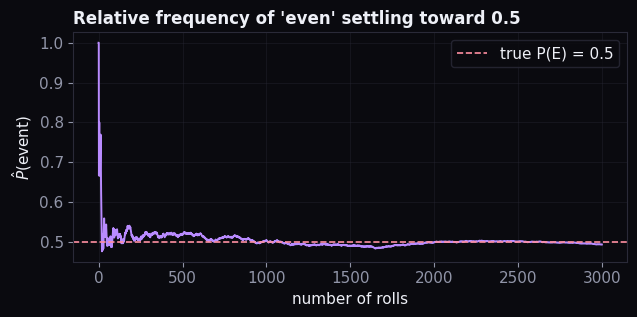

In [2]:
rolls = rng.integers(1, 7, size=20000)
event = np.isin(rolls, [2, 4, 6])
print(f"P(even) empirical = {event.mean():.4f}   theoretical = {3/6:.4f}")

running = np.cumsum(event) / np.arange(1, len(event) + 1)
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.plot(running[:3000], color=ACCENT, lw=1.4)
ax.axhline(0.5, color=WARN, ls='--', lw=1.2, label='true P(E) = 0.5')
style(ax, "Relative frequency of 'even' settling toward 0.5")
ax.set_xlabel("number of rolls"); ax.set_ylabel(r"$\hat{P}$(event)")
ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=INK)
plt.tight_layout(); plt.show()

## 2. Sample Space

### Intuition
The **sample space** &Omega; is the complete guest list of outcomes for one random experiment — nothing more, nothing left out. One die has 6 seats at the table; two dice have 36.

### The math
$$|\Omega| = n_1 \times n_2 \times \cdots \times n_k$$

- **n<sub>i</sub>** — number of choices available at step i
- **|&Omega;|** — total equally-likely outcomes overall

**Worked example:** Two dice: |Ω| = 6 × 6 = 36 equally likely pairs

### Why the equation looks like this
If step 1 has n&#8321; outcomes and, no matter which one occurs, step 2 always has n&#8322; outcomes available, then every pairing of a step-1 outcome with a step-2 outcome is a distinct overall outcome. Listing them out gives n&#8321; rows of n&#8322; each — that's exactly what multiplication counts. Addition would only apply if you were choosing step 1 *or* step 2, never both.

### Where this shows up in practice
- Password strength: possible combinations = (alphabet size)^(length)
- Genetics: possible combinations of allele pairs from two parents
- Test-suite design: total input combinations that need coverage

### See it


|Ω| = 36
first 5 outcomes: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5)]


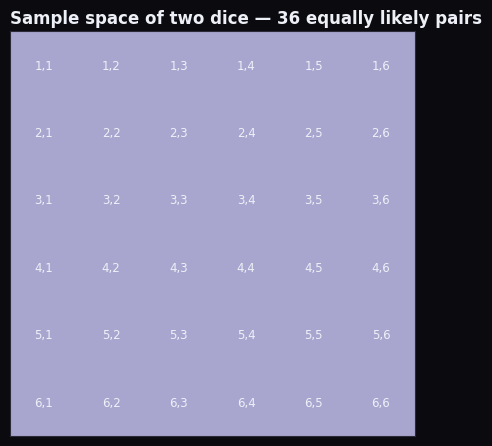

In [3]:
omega = list(itertools.product(range(1, 7), range(1, 7)))
print(f"|Ω| = {len(omega)}")
print("first 5 outcomes:", omega[:5])

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.imshow(np.ones((6, 6)), cmap='Purples', vmin=0, vmax=2.2)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{i+1},{j+1}", ha='center', va='center', color=INK, fontsize=8.5)
ax.set_xticks([]); ax.set_yticks([])
style(ax, "Sample space of two dice — 36 equally likely pairs")
plt.tight_layout(); plt.show()

## 3. Random Variables

### Intuition
A **random variable** X is a rule that turns an outcome into a number. It isn't random and it isn't a variable in the algebra sense — it's a function. Once outcomes become numbers, we can finally add them, average them, and plug them into formulas.

### The math
$$X : \Omega \to \mathbb{R}$$

- **&Omega;** — the raw outcomes of the experiment
- **&#8477;** — the real numbers X assigns to them

**Worked example:** X(face) = face × 10  →  X(4) = 40

### Why the equation looks like this
Calling X a "function from &Omega; to &#8477;" is a precise way of saying: every outcome gets exactly one number, no exceptions, no ambiguity. That precision is what lets us later add values (E[X]), compare them, or plug them into a formula — none of that arithmetic makes sense on raw outcomes like "heads" or "cloudy." Turning outcomes into numbers is the one step that makes the rest of probability theory possible.

### Where this shows up in practice
- Turning categorical outcomes (pass/fail) into numeric scores for analysis
- Financial models: mapping market states to payoff numbers
- Machine learning labels: mapping classes to numeric targets for a loss function

### See it


outcome=1  ->  X=10
outcome=2  ->  X=20
outcome=3  ->  X=30
outcome=4  ->  X=40
outcome=5  ->  X=50
outcome=6  ->  X=60


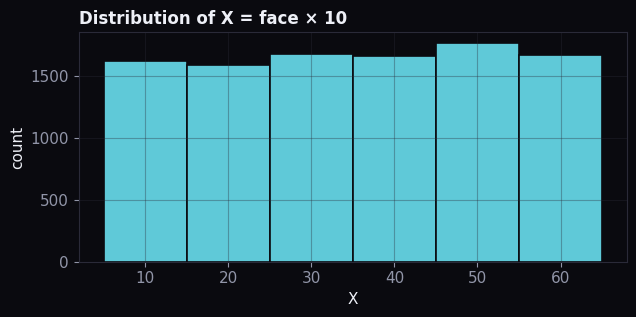

In [4]:
faces = np.arange(1, 7)
X = faces * 10
for f, x in zip(faces, X):
    print(f"outcome={f}  ->  X={x}")

sim_rolls = rng.integers(1, 7, size=10000)
X_sim = sim_rolls * 10
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.hist(X_sim, bins=np.arange(5, 66, 10), color=ACCENT2, edgecolor=BG, linewidth=1.2)
style(ax, "Distribution of X = face × 10")
ax.set_xlabel("X"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 4. PMF

### Intuition
For a **discrete** random variable, the Probability Mass Function hands each possible value of X its own little pile of probability. All the piles together sum to exactly one whole.

### The math
$$P(X = x) = p(x), \qquad \sum_x p(x) = 1$$

- **p(x)** — probability mass sitting at value x
- **&sum; p(x) = 1** — every mass together makes a whole

**Worked example:** Two-dice sum: P(X=7) = 6 / 36 ≈ 0.167

### Why the equation looks like this
X is guaranteed to land on *some* value when the experiment runs — that's not optional, it's the definition of a sample space. So the event "X takes some value" has probability exactly 1. The PMF just distributes that one unit of certainty across all the possible values X could take; add up all the little piles and you must get the whole pie back.

### Where this shows up in practice
- Inventory planning: probability of 0, 1, 2… units of demand per day
- Load balancing: probability of k simultaneous requests hitting a server
- Genetics: probability of k dominant alleles among offspring

### See it


P(X=2) = 0.0278
P(X=3) = 0.0556
P(X=4) = 0.0833
P(X=5) = 0.1111
P(X=6) = 0.1389
P(X=7) = 0.1667
P(X=8) = 0.1389
P(X=9) = 0.1111
P(X=10) = 0.0833
P(X=11) = 0.0556
P(X=12) = 0.0278
sum of all probabilities: 1.0


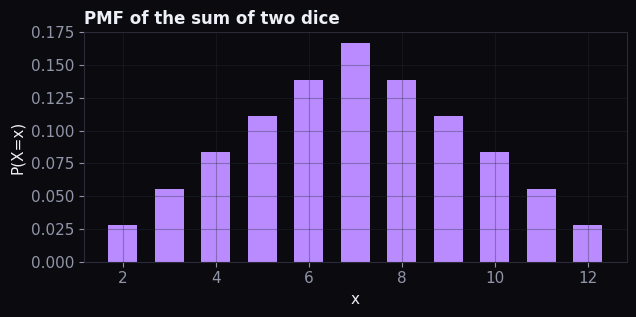

In [5]:
sums = [i + j for i in range(1, 7) for j in range(1, 7)]
counts = Counter(sums)
xs = sorted(counts)
ps = np.array([counts[x] / 36 for x in xs])
for x, p in zip(xs, ps):
    print(f"P(X={x}) = {p:.4f}")
print("sum of all probabilities:", ps.sum())

fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.bar(xs, ps, color=ACCENT, width=0.62)
style(ax, "PMF of the sum of two dice")
ax.set_xlabel("x"); ax.set_ylabel("P(X=x)")
plt.tight_layout(); plt.show()

## 5. PDF

### Intuition
When X is **continuous**, height stops meaning probability. Zoom a histogram's bins narrower and narrower and the jagged bars blur into a smooth curve — that curve is a *density*: probability lives in area, not height.

### The math
$$P(a < X < b) = \int_a^b f(x)\, dx$$

- **f(x)** — density — not a probability by itself, can exceed 1
- **&int;<sub>a</sub><sup>b</sup>** — area swept between a and b

**Worked example:** Heights ~ N(170, 3.2): P(167 < X < 173) ≈ 0.6515

### Why the equation looks like this
A continuous variable can take infinitely many possible values in any interval — if any single exact point had positive probability, and there are infinitely many of them, they'd sum to infinity, which is impossible. So each exact point must carry zero probability, and probability can only accumulate over a stretch of values. Area under a curve is exactly the mathematical tool for accumulating something over a stretch — that's why f(x) is a density (height) and probability is its integral (area).

### Where this shows up in practice
- Manufacturing tolerances: probability a part's dimension falls in spec
- Finance: probability an asset's return falls within a range
- Anomaly detection: modeling a continuous feature's normal range

### See it


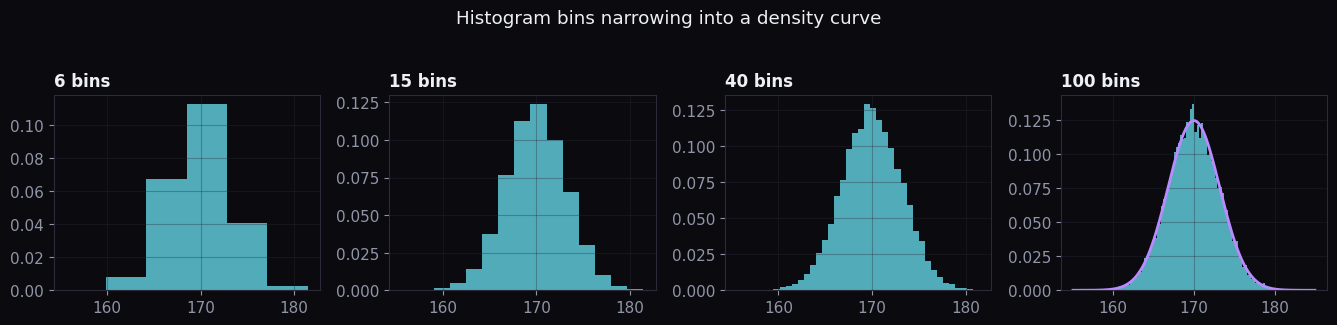

P(167 < X < 173) = 0.6515


In [6]:
heights = rng.normal(170, 3.2, size=20000)

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.1))
for ax, bins in zip(axes, [6, 15, 40, 100]):
    ax.hist(heights, bins=bins, density=True, color=ACCENT2, alpha=0.85)
    style(ax, f"{bins} bins")
xs = np.linspace(155, 185, 300)
axes[-1].plot(xs, stats.norm.pdf(xs, 170, 3.2), color=ACCENT, lw=2)
plt.suptitle("Histogram bins narrowing into a density curve", color=INK, y=1.04)
plt.tight_layout(); plt.show()

p = stats.norm.cdf(173, 170, 3.2) - stats.norm.cdf(167, 170, 3.2)
print(f"P(167 < X < 173) = {p:.4f}")

## 6. CDF

### Intuition
The Cumulative Distribution Function is the density's *running total*: sweep a line left to right under the curve, tracking cumulative area beneath it. F(x) = P(X ≤ x), and it only ever climbs from 0 up to 1.

### The math
$$F(x) = P(X \le x) = \int_{-\infty}^{x} f(t)\, dt$$

- **F(x)** — cumulative probability up to and including x
- **&int;<sub>&minus;&infin;</sub><sup>x</sup>** — all the area lying to the left of x

**Worked example:** Standard normal: F(1.0) ≈ 0.841

### Why the equation looks like this
F(x) is nothing more than the PDF's area, accumulated from the far left up to x — a running total. Since density f(t) is never negative, each additional sliver of area you sweep up as x increases can only add to the total or leave it unchanged — it can never subtract. That's precisely why every valid CDF is monotone non-decreasing, climbing from 0 at negative infinity to 1 at positive infinity.

### Where this shows up in practice
- SLAs: reading p95/p99 latency is just reading the CDF at 0.95 / 0.99
- Percentile ranks on standardized tests
- Risk models: Value-at-Risk is a quantile (inverse CDF) of a loss distribution

### See it


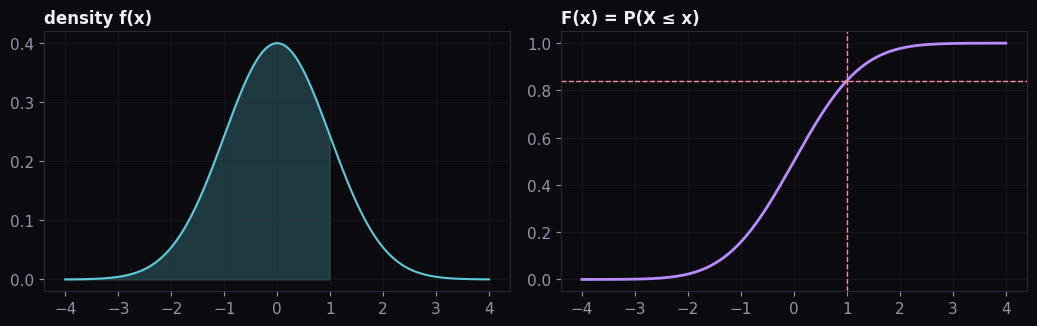

F(1.0) = 0.8413


In [7]:
xs = np.linspace(-4, 4, 400)
pdf, cdf = stats.norm.pdf(xs), stats.norm.cdf(xs)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].plot(xs, pdf, color=ACCENT2)
axes[0].fill_between(xs, pdf, 0, where=(xs <= 1), color=ACCENT2, alpha=0.25)
style(axes[0], "density f(x)")
axes[1].plot(xs, cdf, color=ACCENT, lw=2)
axes[1].axhline(stats.norm.cdf(1), color=WARN, ls='--', lw=1)
axes[1].axvline(1, color=WARN, ls='--', lw=1)
style(axes[1], "F(x) = P(X ≤ x)")
plt.tight_layout(); plt.show()
print("F(1.0) =", round(stats.norm.cdf(1.0), 4))

## 7. Conditional Probability

### Intuition
The moment you know event B happened, every outcome outside B becomes impossible. Probability recalculates inside the smaller world that remains — learning something shrinks your universe.

### The math
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

- **A &cap; B** — both events happening together
- **P(B)** — the new, shrunk universe you're measuring against

**Worked example:** P(rain | cloudy) = 0.18 / 0.42 ≈ 0.43

### Why the equation looks like this
Once you know B happened, B becomes your entire world — outcomes outside B are no longer possible. So you re-measure A only among the outcomes still alive, which is A&cap;B, and re-express it as a fraction of the new whole, which is B. Dividing by P(B) is exactly the rescaling operation that turns "part of the old world" into "part of the new, smaller world."

### Where this shows up in practice
- Medical diagnostics: P(disease | positive test result)
- Recommendation engines: P(purchase | viewed similar items)
- Fraud detection: P(fraud | transaction flagged as suspicious)

### See it


P(rain)            = 0.2103
P(rain | cloudy)   = 0.4519


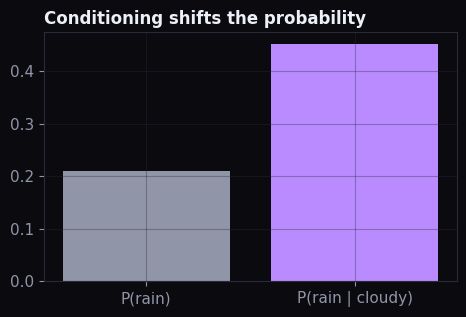

In [8]:
n = 200_000
cloudy = rng.random(n) < 0.40
rain = np.where(cloudy, rng.random(n) < 0.45, rng.random(n) < 0.05)

p_rain = rain.mean()
p_rain_given_cloudy = rain[cloudy].mean()
print(f"P(rain)            = {p_rain:.4f}")
print(f"P(rain | cloudy)   = {p_rain_given_cloudy:.4f}")

fig, ax = plt.subplots(figsize=(4.8, 3.3))
ax.bar(["P(rain)", "P(rain | cloudy)"], [p_rain, p_rain_given_cloudy], color=[DIM, ACCENT])
style(ax, "Conditioning shifts the probability")
plt.tight_layout(); plt.show()

## 8. Bayes' Rule

### Intuition
Bayes' rule lets you update a belief the moment evidence arrives: start with a prior, multiply by how likely the evidence is under that belief, rescale so it's a probability again — what's left is the posterior.

### The math
$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}$$

- **P(A)** — prior belief, before seeing evidence
- **P(B|A)** — likelihood of this evidence, if A were true
- **P(B)** — overall probability of seeing this evidence at all

**Worked example:** prior 1%, sensitivity 90%, false-positive rate 5% → posterior ≈ 15.4%

### Why the equation looks like this
The definition of conditional probability can be written two equivalent ways: P(A&cap;B) = P(A|B)&middot;P(B), and also P(A&cap;B) = P(B|A)&middot;P(A). Since both equal the same P(A&cap;B), set them equal to each other and solve for P(A|B) — the prior &times; likelihood &divide; evidence structure falls out automatically. Bayes' rule is just that one rearrangement, not a separate assumption.

### Where this shows up in practice
- Spam filters updating the odds an email is spam after seeing a trigger word
- Medical testing: correctly interpreting what a positive result really means
- Search and recommendation ranking: updating relevance after a click

### See it


P(sick | positive test) = 0.1538


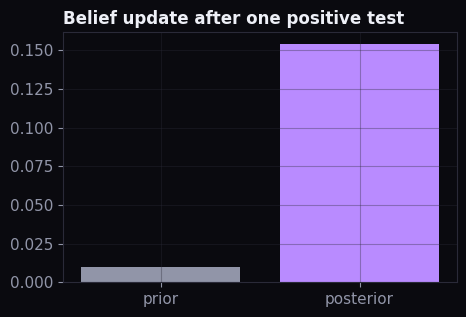

In [9]:
prior, sens, fpr = 0.01, 0.90, 0.05
evidence = prior * sens + (1 - prior) * fpr
posterior = prior * sens / evidence
print(f"P(sick | positive test) = {posterior:.4f}")

fig, ax = plt.subplots(figsize=(4.8, 3.3))
ax.bar(["prior", "posterior"], [prior, posterior], color=[DIM, ACCENT])
style(ax, "Belief update after one positive test")
plt.tight_layout(); plt.show()

## 9. Gaussian Distribution

### Intuition
Take many small independent random nudges and land somewhere; do that thousands of times and the landing spots pile into the same bell shape, no matter what the nudges were. This is why the Gaussian shows up everywhere.

### The math
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \; e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

- **&mu;** — mean — where the curve is centered
- **&sigma;** — standard deviation — how wide it spreads

**Worked example:** μ=170, σ=3.2 → peak density f(170) ≈ 0.125

### Why the equation looks like this
The exponent squares the distance from &mu; so that being twice as far from the mean costs four times as much likelihood — exactly the pattern that emerges when you add up many small independent effects (a preview of the Central Limit Theorem, section 19). The 1/(&sigma;&radic;2&pi;) out front isn't arbitrary decoration — it's precisely the number needed to make the total area under the curve equal exactly 1, a fact that falls out of a classic (and famously non-obvious) integral.

### Where this shows up in practice
- Manufacturing: modeling measurement error around a target value
- Finance: approximating daily return distributions
- Standardized testing: modeling score distributions across a population

### See it


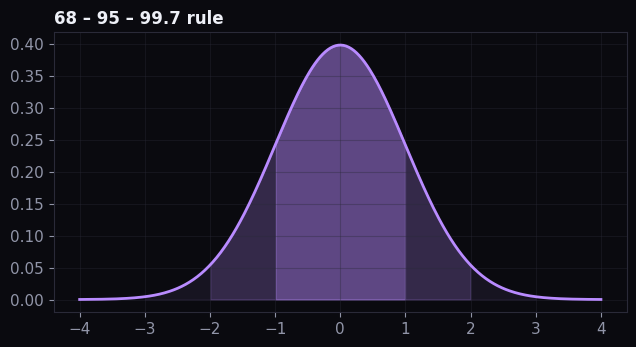

±1σ contains 0.6827 of the area
±2σ contains 0.9545 of the area
±3σ contains 0.9973 of the area


In [10]:
xs = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(xs, stats.norm.pdf(xs), color=ACCENT, lw=2)
for k, a in zip([1, 2, 3], [0.32, 0.18, 0.08]):
    ax.fill_between(xs, stats.norm.pdf(xs), 0, where=(np.abs(xs) <= k), color=ACCENT, alpha=a)
style(ax, "68 – 95 – 99.7 rule")
plt.tight_layout(); plt.show()

for k in [1, 2, 3]:
    print(f"±{k}σ contains {stats.norm.cdf(k) - stats.norm.cdf(-k):.4f} of the area")

## 10. Bernoulli

### Intuition
The simplest random experiment: one flip, two outcomes. Success with probability p, failure with probability 1&minus;p. Every more complex distribution in this notebook is built by stacking these atoms together.

### The math
$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

- **p** — probability of success on this one trial
- **k** — the outcome: 1 = success, 0 = failure

**Worked example:** Fair coin: P(X=1) = 0.5¹·0.5⁰ = 0.5

### Why the equation looks like this
Watch what happens at each value of k: when k=1, the second factor becomes (1&minus;p)&#8304; = 1, leaving just p. When k=0, the first factor becomes p&#8304; = 1, leaving just 1&minus;p. One compact expression silently switches between the two cases depending on k — no if/else needed, just exponent rules doing the work.

### Where this shows up in practice
- Click or no-click on an advertisement
- Pass or fail on a single test or inspection
- Any single yes/no experiment — the atom every other distribution here is built from

### See it


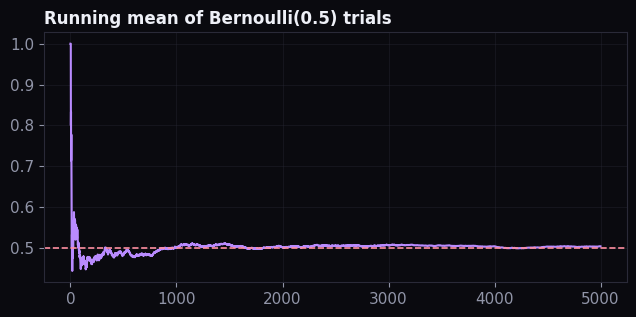

final estimate: 0.5046


In [11]:
p = 0.5
x = rng.binomial(1, p, size=5000)
running = np.cumsum(x) / np.arange(1, len(x) + 1)

fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.plot(running, color=ACCENT)
ax.axhline(p, color=WARN, ls='--', lw=1.2)
style(ax, "Running mean of Bernoulli(0.5) trials")
plt.tight_layout(); plt.show()
print("final estimate:", round(running[-1], 4))

## 11. Binomial

### Intuition
Stack n independent Bernoullis and just count the successes. As n grows, the jagged binomial bars start looking suspiciously like a bell curve — a preview of the Central Limit Theorem.

### The math
$$P(X = k) = \binom{n}{k}\, p^k (1-p)^{n-k}$$

- **C(n,k)** — number of ways to choose which k trials succeed
- **n, p** — number of trials, and success probability per trial

**Worked example:** 10 flips, fair coin: P(X=5) = C(10,5)·0.5¹⁰ ≈ 0.246

### Why the equation looks like this
Any *one specific sequence* with exactly k successes and n&minus;k failures has probability p<sup>k</sup>(1&minus;p)<sup>n&minus;k</sup> — that part is just independent Bernoullis multiplying. But there are many different sequences that all produce the same count k (success-success-failure looks different from failure-success-success, yet both have k=2). C(n,k) counts exactly how many such sequences exist, so you multiply by it to add up all the equally-probable ways of reaching the same total.

### Where this shows up in practice
- Quality control: number of defective items in a batch of n
- A/B testing: number of conversions out of n visitors
- Genetics: number of offspring inheriting a trait out of n

### See it


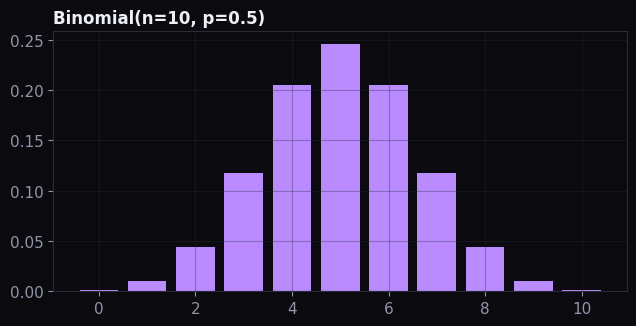

simulated mean: 4.98225  theoretical n·p: 5.0
simulated var:  2.476  theoretical n·p·(1-p): 2.5


In [12]:
n, p = 10, 0.5
ks = np.arange(0, n + 1)
pmf = stats.binom.pmf(ks, n, p)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(ks, pmf, color=ACCENT)
style(ax, f"Binomial(n={n}, p={p})")
plt.tight_layout(); plt.show()

sim = rng.binomial(n, p, size=20000)
print("simulated mean:", sim.mean(), " theoretical n·p:", n * p)
print("simulated var: ", round(sim.var(), 3), " theoretical n·p·(1-p):", n * p * (1 - p))

## 12. Poisson

### Intuition
Count rare events over a fixed stretch of time. Events arrive at random moments, independently, at some average rate &lambda; per interval — no fixed number of "trials," just a rate and a window to count within.

### The math
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

- **&lambda;** — average rate of events per interval
- **k!** — accounts for the orderings of the k arrivals

**Worked example:** λ=4 calls/hour: P(X=6) = 4⁶e⁻⁴/6! ≈ 0.104

### Why the equation looks like this
Take a Binomial(n,p) and let the number of trials n grow toward infinity while p shrinks toward zero, keeping their product n&middot;p fixed at &lambda; — that's "chop the interval into infinitely many infinitesimally-likely sub-trials." Taking that limit of the binomial formula, the n and the combinatorial term reshape themselves into e<sup>&minus;&lambda;</sup> and &lambda;<sup>k</sup>/k!. That's why Poisson has no visible n: it's already baked into &lambda;.

### Where this shows up in practice
- Call centers: number of calls arriving per hour
- Site reliability: number of errors or crashes per minute
- Insurance: number of claims arriving per year

### See it


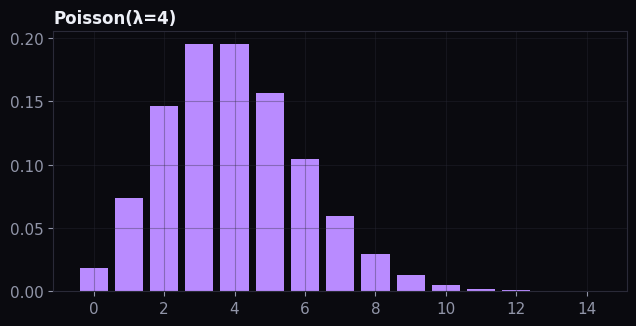

simulated mean: 3.999  simulated variance: 4.07  (both ≈ λ)


In [13]:
lam = 4
ks = np.arange(0, 15)
pmf = stats.poisson.pmf(ks, lam)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(ks, pmf, color=ACCENT)
style(ax, f"Poisson(λ={lam})")
plt.tight_layout(); plt.show()

sim = rng.poisson(lam, 20000)
print("simulated mean:", round(sim.mean(), 3), " simulated variance:", round(sim.var(), 3), " (both ≈ λ)")

## 13. Exponential

### Intuition
The waiting time between Poisson arrivals isn't evenly spaced — it decays: short waits are common, long waits rarer and rarer. It is famously **memoryless**: however long you've already waited, the remaining wait looks exactly the same as starting fresh.

### The math
$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

- **&lambda;** — rate — the same &lambda; as the underlying Poisson process
- **x** — waiting time (must be non-negative)

**Worked example:** λ=1.2/min: P(wait < 1) = 1 − e⁻¹·² ≈ 0.699

### Why the equation looks like this
If arrivals follow a Poisson process with rate &lambda;, then "the wait until the next arrival exceeds t" is exactly the same event as "zero arrivals occurred in the interval [0,t]." Plugging k=0 into the Poisson formula gives P(zero arrivals) = e<sup>&minus;&lambda;t</sup>. So P(wait &gt; t) = e<sup>&minus;&lambda;t</sup>, and differentiating (1 minus that) with respect to t hands you the density f(x) = &lambda;e<sup>&minus;&lambda;x</sup> directly.

### Where this shows up in practice
- Reliability engineering: time until a component fails
- Queueing systems: time between customer arrivals
- Networking: time between packet arrivals on a link

### See it


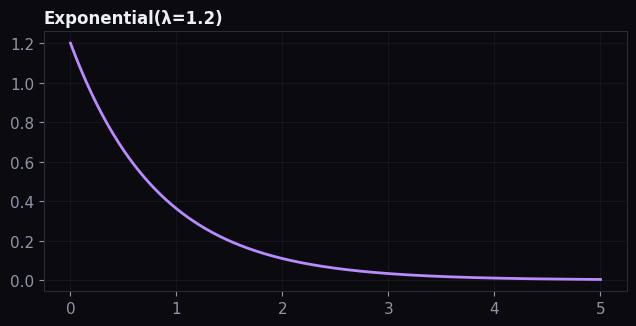

P(wait > t+s | already waited t) = 0.5486
P(wait > s) from scratch         = 0.5487   (essentially identical)


In [14]:
lam = 1.2
xs = np.linspace(0, 5, 300)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(xs, stats.expon.pdf(xs, scale=1 / lam), color=ACCENT, lw=2)
style(ax, f"Exponential(λ={lam})")
plt.tight_layout(); plt.show()

# --- memorylessness check ---
sim = rng.exponential(1 / lam, 500_000)
t, s = 1.0, 0.5
already_waited_t = sim[sim > t]
p_extra_wait = (already_waited_t - t > s).mean()
p_fresh_wait = (sim > s).mean()
print(f"P(wait > t+s | already waited t) = {p_extra_wait:.4f}")
print(f"P(wait > s) from scratch         = {p_fresh_wait:.4f}   (essentially identical)")

## 14. Uniform

### Intuition
Every point between a and b is exactly as likely as every other. No favorite outcome anywhere in the range — the density is a flat rectangle, the simplest shape probability can take.

### The math
$$f(x) = \frac{1}{b-a}, \quad a \le x \le b$$

- **a, b** — the lower and upper bounds of the interval
- **f(x)** — constant density — every point equally dense

**Worked example:** a=0, b=10: f(x) = 1/10 = 0.1 everywhere on [0,10]

### Why the equation looks like this
If you truly have no reason to favor any point over any other, then any two equal-length sub-intervals must carry equal probability — that's what "no preference" means numerically. The only density function that gives every equal-length slice the same area is a flat, constant one. And that constant has to be exactly 1/(b&minus;a) so the whole rectangle's area (base &times; height) works out to 1.

### Where this shows up in practice
- Random ID and hash generation
- Monte Carlo simulation seeds and sampling
- Load balancers choosing a server uniformly at random

### See it


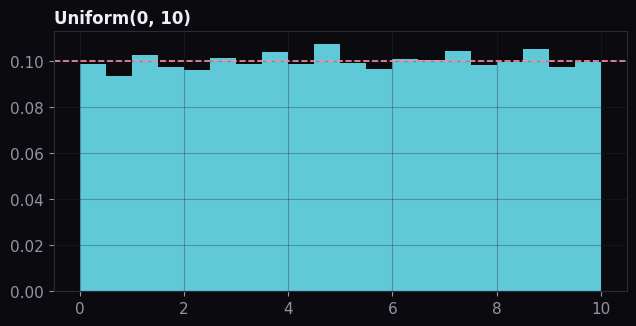

mean: 5.022  theoretical: 5.0
std:  2.875  theoretical: 2.887


In [15]:
a, b = 0, 10
sim = rng.uniform(a, b, 20000)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(sim, bins=20, color=ACCENT2, density=True)
ax.axhline(1 / (b - a), color=WARN, ls='--', lw=1.2)
style(ax, f"Uniform({a}, {b})")
plt.tight_layout(); plt.show()

print("mean:", round(sim.mean(), 3), " theoretical:", (a + b) / 2)
print("std: ", round(sim.std(), 3), " theoretical:", round((b - a) / np.sqrt(12), 3))

## 15. Independence

### Intuition
Two events are independent when learning that one happened leaves your belief about the other completely unchanged — knowing one tells you nothing about the other.

### The math
$$P(A \cap B) = P(A) \cdot P(B)$$

- **P(A)** — unconditional probability of A, on its own
- **P(B)** — unconditional probability of B, on its own

**Worked example:** Two fair coins: P(HH) = 0.5 × 0.5 = 0.25

### Why the equation looks like this
"Independent" means P(A|B) = P(A) — learning B happened doesn't move your belief about A at all. Substitute that into the definition of conditional probability, P(A|B) = P(A&cap;B)/P(B), and solve: P(A) = P(A&cap;B)/P(B), which rearranges to P(A&cap;B) = P(A)&middot;P(B). The multiplication rule isn't a separate assumption — it's what "no influence" looks like once you do the algebra.

### Where this shows up in practice
- Assessing whether two system failures are genuinely unrelated
- Combining two independent sensor readings
- Statistical tests that assume independently drawn samples

### See it


P(both = 1) empirical = 0.2496
P(A) · P(B)           = 0.2504


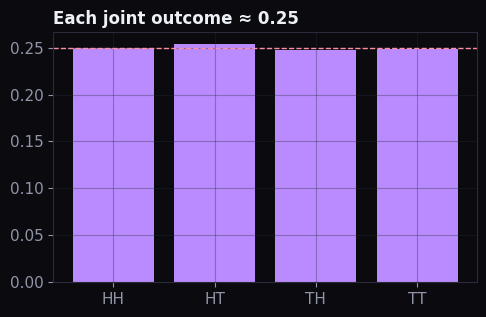

In [16]:
a = rng.integers(0, 2, 50000)
b = rng.integers(0, 2, 50000)
p_both = ((a == 1) & (b == 1)).mean()
p_product = (a == 1).mean() * (b == 1).mean()
print(f"P(both = 1) empirical = {p_both:.4f}")
print(f"P(A) · P(B)           = {p_product:.4f}")

fig, ax = plt.subplots(figsize=(5, 3.3))
combos = ['HH', 'HT', 'TH', 'TT']
freqs = [((a==1)&(b==1)).mean(), ((a==1)&(b==0)).mean(), ((a==0)&(b==1)).mean(), ((a==0)&(b==0)).mean()]
ax.bar(combos, freqs, color=ACCENT)
ax.axhline(0.25, color=WARN, ls='--', lw=1)
style(ax, "Each joint outcome ≈ 0.25")
plt.tight_layout(); plt.show()

## 16. Expectation

### Intuition
Weight each value by how likely it is, then find where the see-saw balances — that balance point is the expected value. Not the most likely outcome, but the long-run average.

### The math
$$E[X] = \sum_x x \cdot P(x)$$

- **x** — a possible value X could take
- **P(x)** — the weight given to that value

**Worked example:** Dice sum: E[X] = 2(1/36)+3(2/36)+⋯+12(1/36) = 7

### Why the equation looks like this
Multiplying each value by its probability and summing is exactly the formula for a center of mass, where "probability" plays the role of "weight." Values that occur more often pull the balance point toward themselves harder — just like heavier objects pull a see-saw's balance point toward them. That's why E[X] can land on a value X itself never actually takes (like 3.5 for a die): it's a balance point, not a most-likely outcome.

### Where this shows up in practice
- Expected value of a bet, lottery ticket, or investment
- Capacity planning: expected load per second on a system
- Insurance: expected payout per policy, used to set premiums

### See it


In [17]:
xs = np.arange(2, 13)
ps = np.array([counts[x] / 36 for x in xs])
ev_theoretical = (xs * ps).sum()
print("E[X] theoretical:", ev_theoretical)

sim = rng.integers(1, 7, 100000) + rng.integers(1, 7, 100000)
print("E[X] simulated:  ", sim.mean())

E[X] theoretical: 6.999999999999998
E[X] simulated:   6.99268


## 17. Variance & Standard Deviation

### Intuition
Measure each outcome's distance from the mean, square it so direction can't cancel out, then average those squares. The standard deviation brings it back to the original units.

### The math
$$\mathrm{Var}(X) = E[(X-\mu)^2] = E[X^2] - (E[X])^2$$

- **&mu;** — the mean, E[X]
- **(X&minus;&mu;)&sup2;** — squared distance of each value from the mean

**Worked example:** x=[2,4,4,4,5,5,7,9], μ=5 → Var(X) = 4.0

### Why the equation looks like this
If you just averaged the raw deviations (X&minus;&mu;), positive and negative deviations always cancel exactly — the average deviation from the mean is *always* zero, by the very definition of the mean. That tells you nothing about spread. Squaring first forces every deviation to contribute positively, so values far from &mu; (in either direction) genuinely increase the total. The second form, E[X&sup2;]&minus;(E[X])&sup2;, is just an algebraic shortcut for computing the same quantity.

### Where this shows up in practice
- Quality control: consistency of a manufacturing process
- Finance: volatility (risk) of an asset's returns
- Reliability: consistency of a system's response times

### See it


mean: 5.0  variance: 4.0  std: 2.0
numpy check -> var: 4.0  std: 2.0


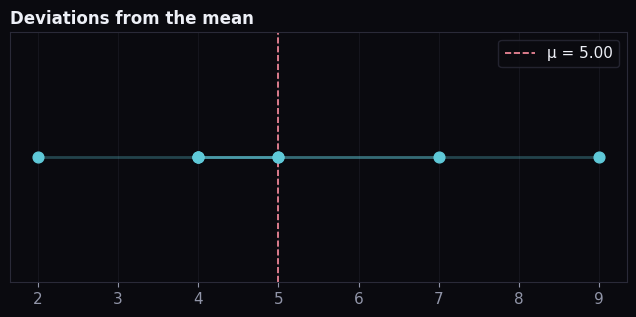

In [18]:
data = np.array([2, 4, 4, 4, 5, 5, 7, 9])
mu = data.mean()
var = ((data - mu) ** 2).mean()
print("mean:", mu, " variance:", var, " std:", np.sqrt(var))
print("numpy check -> var:", data.var(), " std:", data.std())

fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.scatter(data, np.zeros_like(data), color=ACCENT2, s=60, zorder=3)
for d in data:
    ax.plot([mu, d], [0, 0], color=ACCENT2, alpha=0.3, lw=2)
ax.axvline(mu, color=WARN, ls='--', lw=1.2, label=f"μ = {mu:.2f}")
style(ax, "Deviations from the mean")
ax.set_yticks([]); ax.legend(facecolor=BG, edgecolor=GRID, labelcolor=INK)
plt.tight_layout(); plt.show()

## 18. Law of Large Numbers

### Intuition
A single coin flip is a coin flip. But the running average of a thousand flips barely wiggles — it locks onto the true probability. Random per trial, predictable in aggregate.

### The math
$$\frac{1}{n}\sum_{i=1}^{n} X_i \;\longrightarrow\; \mu \quad \text{as } n \to \infty$$

- **X<sub>i</sub>** — each individual, independent trial outcome
- **n &rarr; &infin;** — as the number of trials grows without bound

**Worked example:** n=10: sample mean ≈ 0.60  ·  n=10,000: sample mean ≈ 0.4998

### Why the equation looks like this
Averaging n independent copies of X shrinks the *variance* of that average by a factor of n: Var(mean) = Var(X)/n. That's because independent random wiggles partially cancel each other out rather than stacking up. As n grows without bound, Var(X)/n shrinks toward zero — and a random quantity with vanishing variance has nowhere left to go but its own mean. That's the whole proof sketch in one line.

### Where this shows up in practice
- Casinos profit reliably even though each individual bet is random
- Insurance pricing relies on pooling large numbers of independent policies
- Polling: larger sample sizes shrink the margin of error

### See it


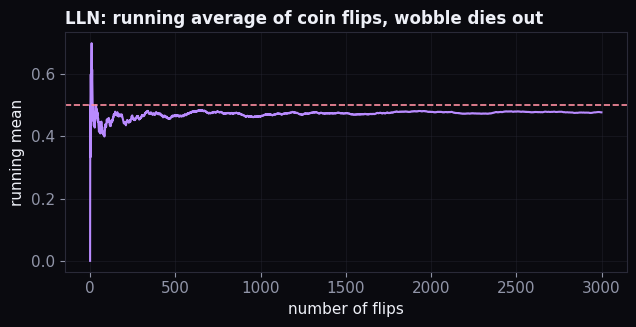

n=10    running mean = 0.7000
n=100   running mean = 0.4500
n=1000  running mean = 0.4640
n=3000  running mean = 0.4777


In [19]:
n = 3000
flips = rng.integers(0, 2, n)
running = np.cumsum(flips) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(running, color=ACCENT)
ax.axhline(0.5, color=WARN, ls='--', lw=1.2)
style(ax, "LLN: running average of coin flips, wobble dies out")
ax.set_xlabel("number of flips"); ax.set_ylabel("running mean")
plt.tight_layout(); plt.show()

for k in [10, 100, 1000, 3000]:
    print(f"n={k:<5} running mean = {running[k-1]:.4f}")

## 19. Central Limit Theorem

### Intuition
Start with a lopsided, totally non-Gaussian distribution. Average small batches of draws, repeat that thousands of times — those averages pile into a bell curve anyway.

### The math
$$\frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \;\longrightarrow\; N(0, 1)$$

- **X&#772;** — the sample mean of n independent draws
- **&sigma;/&radic;n** — the standard error — shrinks as n grows

**Worked example:** Averaging 30 exponential(1) draws: X̄ ≈ N(1, 0.183²)

### Why the equation looks like this
However lopsided one single draw is, a *sum* of many independent draws spreads its randomness across many small, roughly-equal contributions — no single draw can dominate the total once there are enough of them. That symmetric piling-up of many small, independent nudges is precisely the mechanism that produces a Gaussian shape (as we saw for the Gaussian itself in section 9). The astonishing part is that this works regardless of the shape you started from.

### Where this shows up in practice
- Confidence intervals around any sample mean, whatever the raw data looks like
- Quality-control charts that assume approximately normal sample means
- A/B test significance testing

### See it


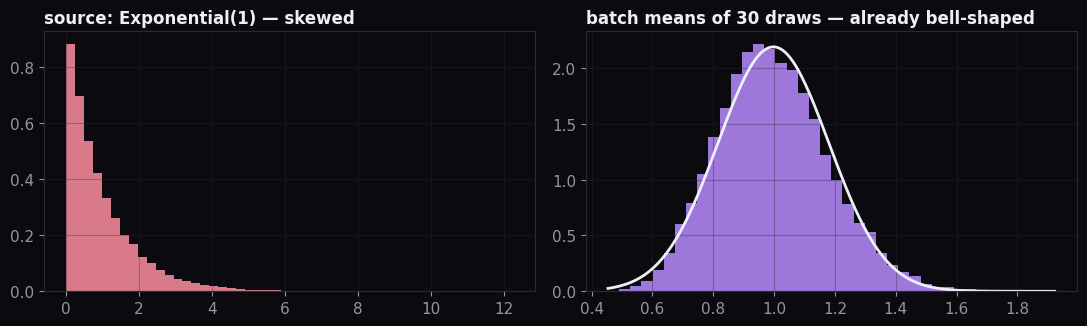

mean of means: 0.998  std of means: 0.182


In [20]:
raw = rng.exponential(1, size=(20000, 30))
means = raw.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(raw[:, 0], bins=50, density=True, color=WARN, alpha=0.85)
style(axes[0], "source: Exponential(1) — skewed")
axes[1].hist(means, bins=40, density=True, color=ACCENT, alpha=0.85)
xs = np.linspace(means.min(), means.max(), 200)
axes[1].plot(xs, stats.norm.pdf(xs, means.mean(), means.std()), color=INK, lw=2)
style(axes[1], "batch means of 30 draws — already bell-shaped")
plt.tight_layout(); plt.show()

print("mean of means:", round(means.mean(), 3), " std of means:", round(means.std(), 3))

## 20. Covariance & Correlation

### Intuition
Plot pairs (x, y). If high x tends to come with high y, they're positively correlated; opposite trend, negative; no pattern, zero. Correlation rescales covariance to always sit between &minus;1 and 1.

### The math
$$\rho = \frac{\mathrm{Cov}(X,Y)}{\sigma_X\, \sigma_Y}$$

- **Cov(X,Y)** — how X and Y vary together, in original units
- **&rho; &isin; [&minus;1,1]** — normalized, unit-free strength of the relationship

**Worked example:** CPU load vs. latency: ρ ≈ 0.997 — near-perfect positive

### Why the equation looks like this
Cov(X,Y) averages the product (X&minus;&mu;<sub>X</sub>)(Y&minus;&mu;<sub>Y</sub>). When X and Y tend to sit above their means together (or below together), both deviations share the same sign, so the product is positive — and the average stays positive. When they move in opposite directions, the signs disagree, products go negative, and the average goes negative. Dividing by &sigma;<sub>X</sub>&sigma;<sub>Y</sub> just rescales this raw number into a unit-free score between &minus;1 and 1, so it's comparable across any pair of variables regardless of their units.

### Where this shows up in practice
- Finance: diversifying a portfolio using uncorrelated assets
- Machine learning: dropping highly-correlated features before modeling
- Ops monitoring: detecting whether two metrics (like CPU and latency) move together

### See it


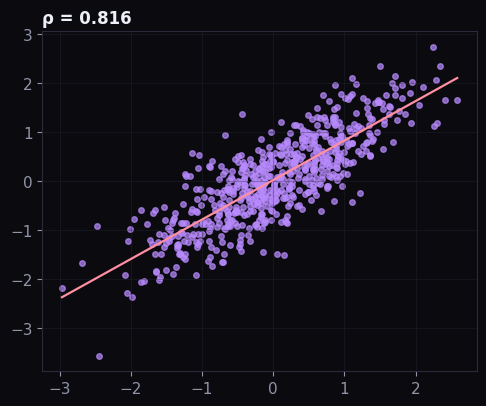

covariance: 0.689  correlation: 0.816


In [21]:
n = 600
x = rng.normal(0, 1, n)
y = 0.8 * x + rng.normal(0, 0.5, n)
cov = np.cov(x, y)[0, 1]
corr = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(5, 4.2))
ax.scatter(x, y, s=16, color=ACCENT, alpha=0.7)
m, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, m * xs + b, color=WARN, lw=1.6)
style(ax, f"ρ = {corr:.3f}")
plt.tight_layout(); plt.show()

print("covariance:", round(cov, 3), " correlation:", round(corr, 3))

---
## Recap

| # | Idea | One-line takeaway |
|---|------|--------------------|
| 1 | Events | probability = counting favorable outcomes over total |
| 2 | Sample Space | list every possible outcome, exhaustively |
| 3 | Random Variables | a function turning outcomes into numbers |
| 4 | PMF | discrete probability piles that sum to 1 |
| 5 | PDF | continuous probability lives in area, not height |
| 6 | CDF | the running total of the PDF |
| 7 | Conditional Probability | rescale to a smaller universe |
| 8 | Bayes' Rule | update a belief given evidence |
| 9 | Gaussian | many small effects summing into a bell curve |
| 10 | Bernoulli | one flip, two outcomes |
| 11 | Binomial | n independent Bernoullis, counted |
| 12 | Poisson | rare events over a fixed interval |
| 13 | Exponential | memoryless waiting time between Poisson events |
| 14 | Uniform | maximum ignorance over an interval |
| 15 | Independence | knowing one tells you nothing about the other |
| 16 | Expectation | the probability-weighted balance point |
| 17 | Variance & Std Dev | average squared distance from the mean |
| 18 | Law of Large Numbers | averages calm down as n grows |
| 19 | Central Limit Theorem | averages become Gaussian regardless of source shape |
| 20 | Covariance & Correlation | do two variables move together? |

*Companion to the "Probability — A Visual Journey" animated HTML deck.*
